Cleaning

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("final_master_dataset.csv")

# Quick check
print(df.shape)
print(df.head())
print(df.isna().sum())

# Drop the 1 missing trifecta value (tiny dataset so this is fine)
df = df.dropna(subset=["trifecta_2024"])


(51, 24)
        state state_abbr  fips_state  poverty_rate  median_household_income  \
0     Alabama         AL           1         0.152                    66659   
1      Alaska         AK           2         0.102                    95665   
2     Arizona         AZ           4         0.117                    81486   
3    Arkansas         AR           5         0.155                    62106   
4  California         CA           6         0.118                   100149   

   white_pct  black_pct  native_pct  asian_pct  pacific_pct  ...  \
0   0.640117   0.252459    0.004960   0.015431     0.001119  ...   
1   0.587084   0.025060    0.140546   0.059553     0.017089  ...   
2   0.573128   0.047593    0.040175   0.039926     0.001796  ...   
3   0.681899   0.141760    0.005490   0.017868     0.003807  ...   
4   0.380758   0.053529    0.014224   0.161029     0.003952  ...   

   trifecta_2024  usda_snap_region  benefits_per_person  minimum_wage  \
0     Republican         Southeast

In [14]:
# Columns we will NOT use as predictors
id_cols   = ["state", "state_abbr", "fips_state"]
leaky_cols = ["benefits_may_2025", "participants_may_2025"]  # directly define benefits/participation

target_reg = "benefits_per_person"
target_clf = "snap_policy_class"

num_features = [
    "poverty_rate",
    "median_household_income",
    "white_pct", "black_pct", "native_pct", "asian_pct", "pacific_pct", "two_plus_pct",
    "grocery_cost_index",
    "minimum_wage",
    "RUCC",
    "population",
    "participants_per_1000",
]

cat_features = [
    "trifecta_2024",
    "usda_snap_region",
    "min_wage_tier",
    "rural_urban_category",
]

# Just to be explicit:
X_all = df[num_features + cat_features]
y_reg = df[target_reg]
y_clf = df[target_clf]


In [15]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)


Plotting

<Figure size 1200x800 with 0 Axes>

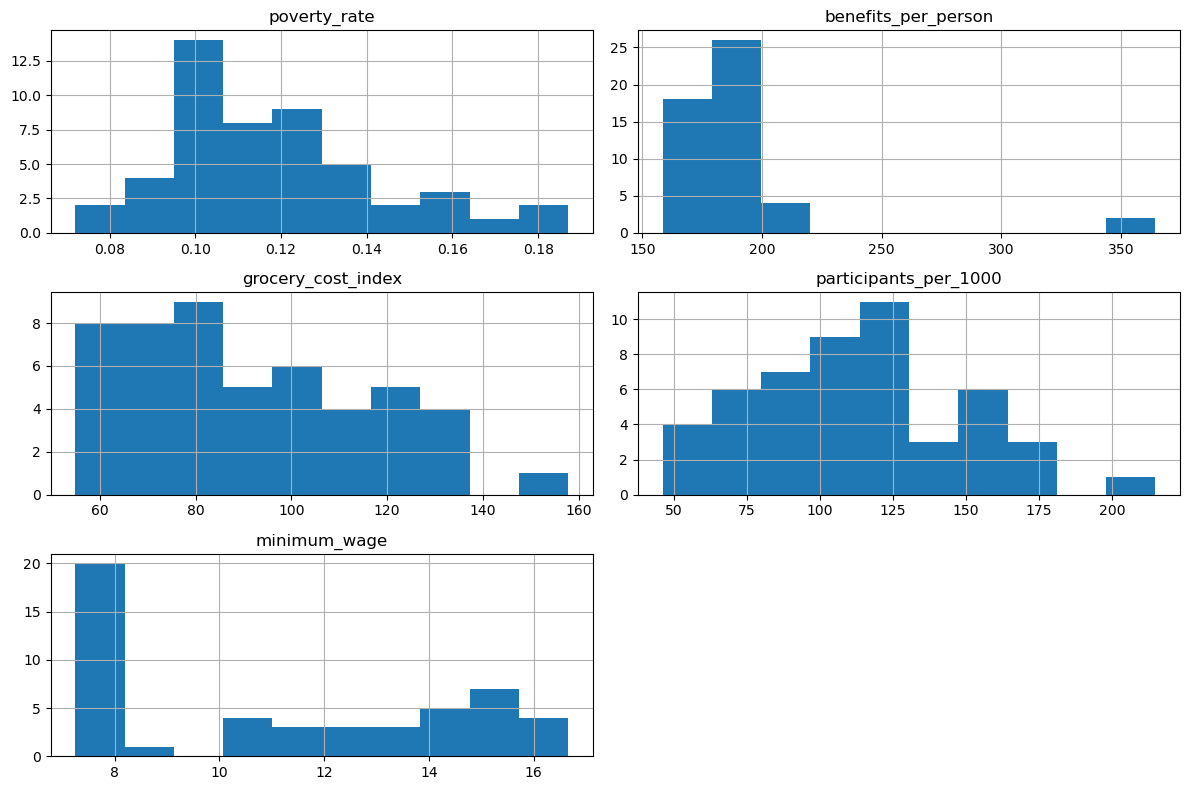

In [16]:
plt.figure(figsize=(12, 8))
df[["poverty_rate", "benefits_per_person", "grocery_cost_index",
    "participants_per_1000", "minimum_wage"]].hist(bins=10, figsize=(12, 8))
plt.tight_layout()
plt.show()


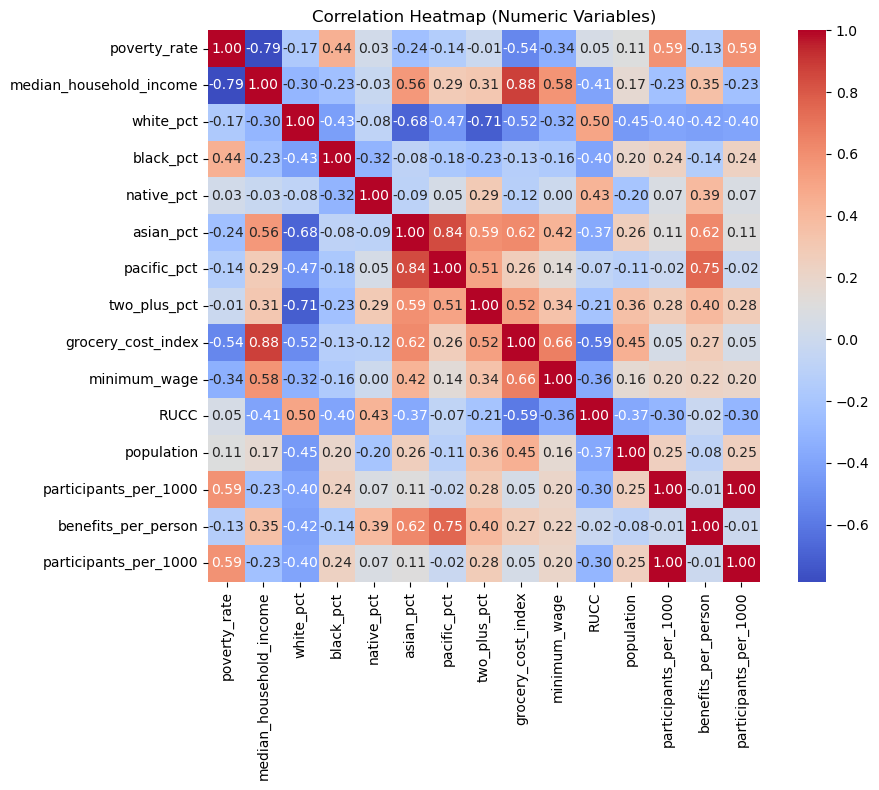

In [17]:
plt.figure(figsize=(10, 8))
corr = df[num_features + [target_reg, "participants_per_1000"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()


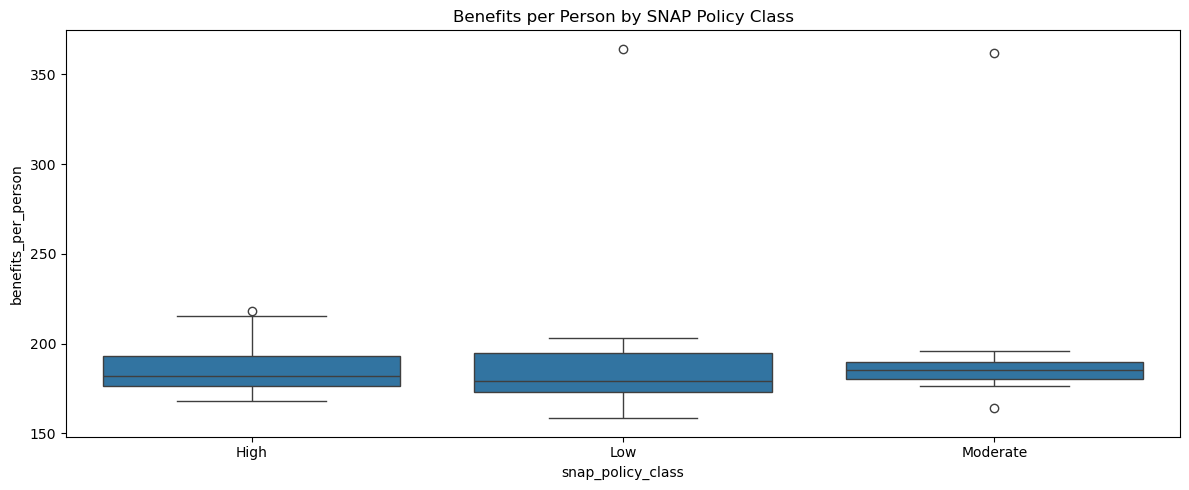

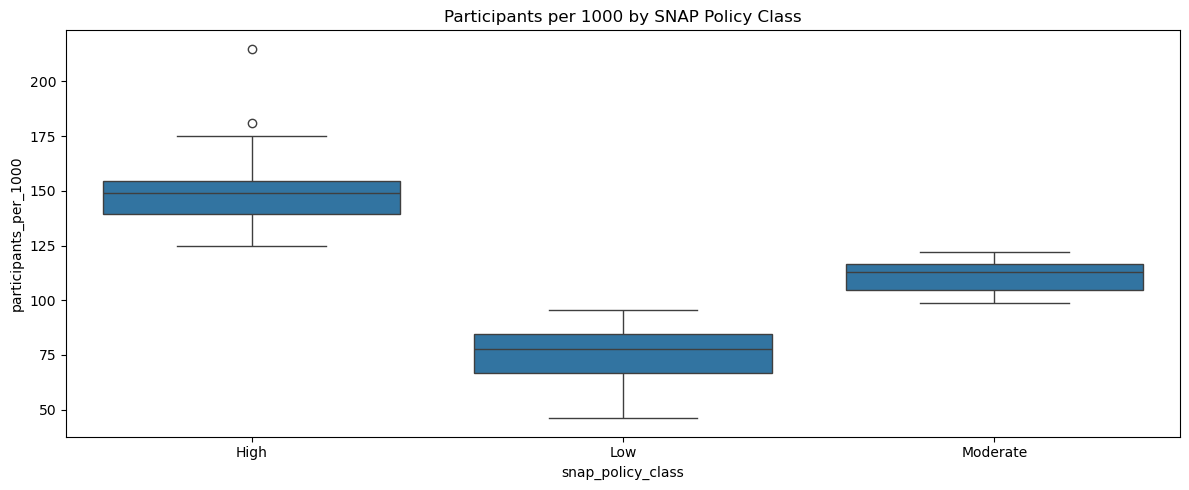

In [6]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="snap_policy_class", y="benefits_per_person")
plt.title("Benefits per Person by SNAP Policy Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="snap_policy_class", y="participants_per_1000")
plt.title("Participants per 1000 by SNAP Policy Class")
plt.tight_layout()
plt.show()


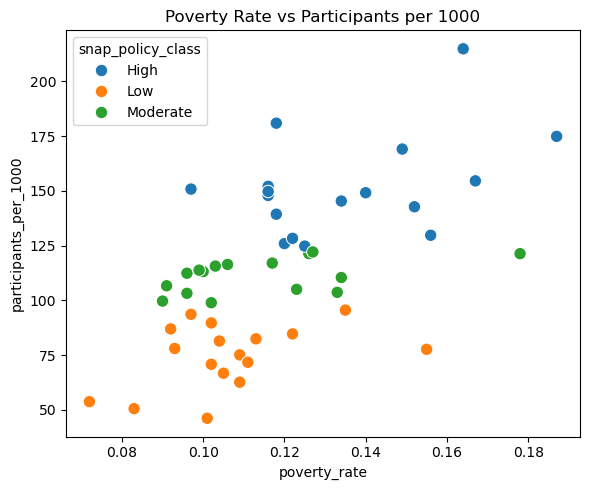

In [7]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df,
                x="poverty_rate", y="participants_per_1000",
                hue="snap_policy_class", s=80)
plt.title("Poverty Rate vs Participants per 1000")
plt.tight_layout()
plt.show()


Modeling

Logistic Regression (GLM) – classify snap_policy_class

In [8]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_all, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        max_iter=500,
        solver="lbfgs"
    ))
])

log_reg_clf.fit(X_train_clf, y_train_clf)

print("Logistic Regression (multinomial) accuracy:")
print("  Train:", log_reg_clf.score(X_train_clf, y_train_clf))
print("  Test :", log_reg_clf.score(X_test_clf, y_test_clf))


Logistic Regression (multinomial) accuracy:
  Train: 1.0
  Test : 0.8


/opt/anaconda3/envs/ds6001/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


cross validation

In [9]:
cv_scores_log = cross_val_score(log_reg_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_log.mean(), "+/-", cv_scores_log.std())


CV accuracy (5-fold): 0.7 +/- 0.16733200530681516


/opt/anaconda3/envs/ds6001/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ds6001/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ds6001/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ds6001/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: F

KNN

In [10]:
knn_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_clf.fit(X_train_clf, y_train_clf)

print("KNN accuracy:")
print("  Train:", knn_clf.score(X_train_clf, y_train_clf))
print("  Test :", knn_clf.score(X_test_clf, y_test_clf))

cv_scores_knn = cross_val_score(knn_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_knn.mean(), "+/-", cv_scores_knn.std())


KNN accuracy:
  Train: 0.65
  Test : 0.7
CV accuracy (5-fold): 0.5599999999999999 +/- 0.10198039027185568


linear regression

In [11]:
X_reg = df[num_features + cat_features]
y_reg = df[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


plain linear

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_train = linreg.predict(X_train_reg)
y_pred_test  = linreg.predict(X_test_reg)

train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test_reg,  y_pred_test))

print("Linear Regression:")
print("  Train RMSE:", train_rmse)
print("  Test  RMSE:", test_rmse)
print("  Train R^2:", r2_score(y_train_reg, y_pred_train))
print("  Test  R^2:", r2_score(y_test_reg,  y_pred_test))


NameError: name 'linreg' is not defined

In [18]:
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso


Ridge

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge.fit(X_train_reg, y_train_reg)

y_pred_test_ridge = ridge.predict(X_test_reg)

ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_ridge))
ridge_r2   = r2_score(y_test_reg, y_pred_test_ridge)

print("Ridge Regression:")
print("  Test RMSE:", ridge_rmse)
print("  Test R^2 :", ridge_r2)


Ridge Regression:
  Test RMSE: 22.90639335004439
  Test R^2 : -5.89772552735395


laso

In [20]:
from sklearn.linear_model import Lasso

lasso = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Lasso(alpha=1.0, max_iter=5000))
])

lasso.fit(X_train_reg, y_train_reg)

y_pred_test_lasso = lasso.predict(X_test_reg)

lasso_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_lasso))
lasso_r2   = r2_score(y_test_reg, y_pred_test_lasso)

print("Lasso Regression:")
print("  Test RMSE:", lasso_rmse)
print("  Test R^2 :", lasso_r2)


Lasso Regression:
  Test RMSE: 24.317288758468283
  Test R^2 : -6.773610645594742


K mean clustering (unsupoervised)

In [21]:
X_cluster = df[num_features]  # only numeric

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

df["cluster_k3"] = cluster_labels
print(df[["state", "cluster_k3", "snap_policy_class", "usda_snap_region"]].head())


        state  cluster_k3 snap_policy_class usda_snap_region
0     Alabama           1              High        Southeast
1      Alaska           0               Low          Western
2     Arizona           2          Moderate        Southwest
3    Arkansas           1               Low        Southwest
4  California           2              High          Western


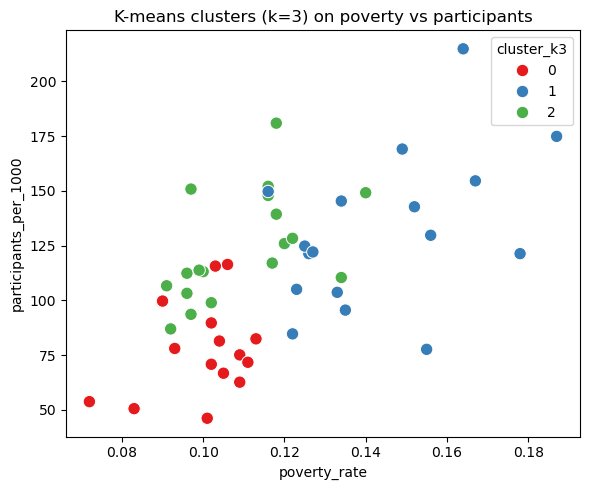

In [22]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df["poverty_rate"],
    y=df["participants_per_1000"],
    hue=df["cluster_k3"],
    palette="Set1",
    s=80
)
plt.title("K-means clusters (k=3) on poverty vs participants")
plt.tight_layout()
plt.show()


PCA dimentioniality reduction

Explained variance by PC1+PC2: 0.564042096094751


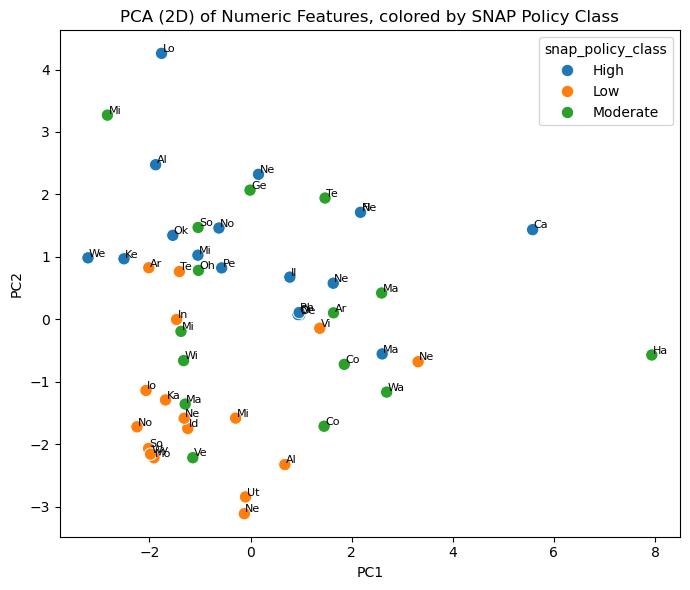

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

print("Explained variance by PC1+PC2:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "snap_policy_class": df["snap_policy_class"],
    "state": df["state"]
})

plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2",
                hue="snap_policy_class", s=80)
for _, row in pca_df.iterrows():
    plt.text(row["PC1"]+0.02, row["PC2"]+0.02, row["state"][:2], fontsize=8)

plt.title("PCA (2D) of Numeric Features, colored by SNAP Policy Class")
plt.tight_layout()
plt.show()


MLP neural network (classification)

In [24]:
mlp_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        max_iter=2000,
        random_state=42
    ))
])

mlp_clf.fit(X_train_clf, y_train_clf)

print("MLP accuracy:")
print("  Train:", mlp_clf.score(X_train_clf, y_train_clf))
print("  Test :", mlp_clf.score(X_test_clf, y_test_clf))

cv_scores_mlp = cross_val_score(mlp_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_mlp.mean(), "+/-", cv_scores_mlp.std())


MLP accuracy:
  Train: 1.0
  Test : 0.7
CV accuracy (5-fold): 0.58 +/- 0.0748331477354788


In [25]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install dash dash-bootstrap-components plotly


Note: you may need to restart the kernel to use updated packages.
